# Agentic RAG — Experimentation Notebook

This notebook lets you test each node and the full graph incrementally as the project is built.

---

## Setup

Run this cell once at the start of every session.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root is one level up from notebooks/

from dotenv import load_dotenv
load_dotenv(os.path.join("..", ".env"))

print("Setup complete. OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))

Setup complete. OPENAI_API_KEY set: True


---
## Step 1 — Graph Skeleton

Verify the graph compiles and all placeholder nodes run.

In [2]:
from src.graph import build_graph

graph = build_graph()
print("Graph compiled OK:", graph)

c:\Users\DELL\OneDrive - scoptanalytics.com\Documents\GitHub\agents-capstone-project-agentic-rag\src\nodes\rag.py:10: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  _vectorstore = Chroma(


Graph compiled OK: <langgraph.graph.state.CompiledStateGraph object at 0x000001A132095160>


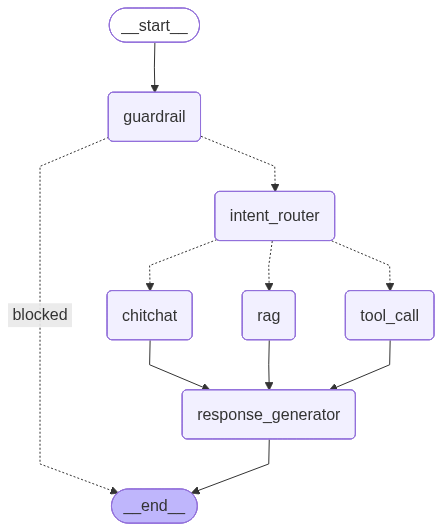

In [3]:
graph

---
## Step 2 — Guardrail Node

Tests the LLM-based safety & scope check.

In [4]:
from src.nodes.guardrail import guardrail_node

# Helper to build a minimal state for testing individual nodes
def make_state(query: str) -> dict:
    return {
        "query": query,
        "messages": [],
        "intent": "",
        "retrieved_docs": [],
        "tool_output": None,
        "guardrail_decision": "",
        "final_response": "",
    }

test_queries = [
    "What is my order status?",       # should PASS
    "Tell me about your return policy",# should PASS
    "Help me hack a website",          # should BLOCK
    "Solve this math equation for me", # should BLOCK (out of scope)
    "Can you write a python code to add two numbers?",
]

for q in test_queries:
    result = guardrail_node(make_state(q))
    print(f"  [{result['guardrail_decision']}] {q!r}")

[guardrail] decision=PASS for query: 'What is my order status?'
  [PASS] 'What is my order status?'
[guardrail] decision=PASS for query: 'Tell me about your return policy'
  [PASS] 'Tell me about your return policy'
[guardrail] decision=BLOCK_HARMFUL for query: 'Help me hack a website'
  [BLOCK] 'Help me hack a website'
[guardrail] decision=BLOCK_SCOPE for query: 'Solve this math equation for me'
  [BLOCK] 'Solve this math equation for me'
[guardrail] decision=BLOCK_SCOPE for query: 'Can you write a python code to add two numbers?'
  [BLOCK] 'Can you write a python code to add two numbers?'


In [5]:
# Test full graph with a PASS query (goes all the way through)
result = graph.invoke(make_state("What is my order status?"))
print("guardrail_decision:", result["guardrail_decision"])
print("final_response    :", result["final_response"])

[guardrail] decision=PASS for query: 'What is my order status?'
[intent_router] intent='tool_call' for query: 'What is my order status?'
[tool_call] LLM did not invoke any tool
[response_generator] tool reply (90 chars)
guardrail_decision: PASS
final_response    : Could you please provide me with your order ID? I'll be happy to check the status for you!


In [6]:
# Test full graph with a BLOCK query (graph ends at guardrail)
result = graph.invoke(make_state("Help me hack a website"))
print("guardrail_decision:", result["guardrail_decision"])
print("final_response    :", result["final_response"])  # will be empty string — graph ended early

[guardrail] decision=BLOCK_HARMFUL for query: 'Help me hack a website'
guardrail_decision: BLOCK
final_response    : I cannot and will not provide assistance with hacking or any illegal activities. This would violate both ShopEasy policies and the law.

I'm here to help you with legitimate shopping needs such as:
- Order status, shipment tracking, and returns
- ShopEasy policies: payments, refunds, and account management
- General information about products and services on ShopEasy

Is there something specific you'd like to shop for or learn about on ShopEasy instead?


In [7]:
# Test full graph with a BLOCK query (graph ends at guardrail)
result = graph.invoke(make_state("Help me commit a fraud in ShopEasy"))
print("guardrail_decision:", result["guardrail_decision"])
print("final_response    :", result["final_response"])  # will be empty string — graph ended early

[guardrail] decision=BLOCK_HARMFUL for query: 'Help me commit a fraud in ShopEasy'
guardrail_decision: BLOCK
final_response    : I cannot and will not provide assistance with hacking or any illegal activities. This would violate both ShopEasy policies and the law.

I'm here to help you with legitimate shopping needs such as:
- Order status, shipment tracking, and returns
- ShopEasy policies: payments, refunds, and account management
- General information about products and services on ShopEasy

Is there something specific you'd like to shop for or learn about on ShopEasy instead?


In [8]:
# Test full graph with a BLOCK query (graph ends at guardrail)
result = graph.invoke(make_state("GIve me a legal advise"))
print("guardrail_decision:", result["guardrail_decision"])
print("final_response    :", result["final_response"])  # will be empty string — graph ended early

[guardrail] decision=BLOCK_SCOPE for query: 'GIve me a legal advise'
guardrail_decision: BLOCK
final_response    : I'm sorry, I can't help with that as I'm a ShopEasy shopping assistant, not a qualified professional for that topic.

However, I can help you with:
- Order status, shipment tracking, and returns
- ShopEasy policies: payments, refunds, and account management
- General information about products and services on ShopEasy

Is there anything shopping-related I can help you with today?


---
## Step 3 — Intent Router

Tests query classification into `rag`, `tool_call`, or `chitchat`.

In [9]:
from src.nodes.intent_router import intent_router_node

test_queries = [
    ("What is your return policy?",          "rag"),
    ("Where is my order #12345?",            "tool_call"),
    ("What payment methods do you accept?",  "rag"),
    ("Cancel my subscription",               "tool_call"),
    ("Hey, how are you?",                    "chitchat"),
    ("Thanks for your help!",                "chitchat"),
]

for q, expected in test_queries:
    result = intent_router_node(make_state(q))
    status = "OK" if result["intent"] == expected else "MISMATCH"
    print(f"  [{status}] intent={result['intent']!r} (expected {expected!r}) | {q!r}")

[intent_router] intent='rag' for query: 'What is your return policy?'
  [OK] intent='rag' (expected 'rag') | 'What is your return policy?'
[intent_router] intent='tool_call' for query: 'Where is my order #12345?'
  [OK] intent='tool_call' (expected 'tool_call') | 'Where is my order #12345?'
[intent_router] intent='rag' for query: 'What payment methods do you accept?'
  [OK] intent='rag' (expected 'rag') | 'What payment methods do you accept?'
[intent_router] intent='tool_call' for query: 'Cancel my subscription'
  [OK] intent='tool_call' (expected 'tool_call') | 'Cancel my subscription'
[intent_router] intent='chitchat' for query: 'Hey, how are you?'
  [OK] intent='chitchat' (expected 'chitchat') | 'Hey, how are you?'
[intent_router] intent='chitchat' for query: 'Thanks for your help!'
  [OK] intent='chitchat' (expected 'chitchat') | 'Thanks for your help!'


In [ ]:
# Test guardrail + intent router together in the full graph
from importlib import reload
import src.graph
reload(src.graph)
from src.graph import build_graph

graph = build_graph()

for q in ["What is your return policy?", "Where is my order #12345?", "Hey, how are you?"]:
    result = graph.invoke(make_state(q))
    print(f"  intent={result['intent']!r} | {q!r}")

---
## Step 4 — RAG Node

### Stage 1 — Document Loader

Load PDF files from `data/docs/` using LangChain's `PyPDFDirectoryLoader`.

In [11]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_core.documents import Document
from collections import defaultdict
import re

DATA_DIR = os.path.join("..", "data", "docs")

loader = PyPDFDirectoryLoader(DATA_DIR, extract_images=False)
pages = loader.load()

# Merge pages per PDF
merged = defaultdict(lambda: {"text": ""})
for page in pages:
    src = page.metadata["source"]
    merged[src]["text"] += page.page_content + "\n"

def parse_header(text: str) -> tuple[dict, str]:
    """Strip title, version, effective date, department from top and store in metadata."""
    lines = text.strip().split("\n")
    meta = {"title": "", "version": "", "effective_date": "", "department": ""}
    consume = 0

    for i, line in enumerate(lines):
        line_stripped = line.strip()
        if i == 0:
            meta["title"] = line_stripped
            consume += 1
        elif re.match(r"Version\s+[\d.]+", line_stripped):
            version_match = re.search(r"Version\s+([\d.]+)", line_stripped)
            date_match = re.search(r"Effective Date:\s*(.+)", line_stripped)
            if version_match:
                meta["version"] = version_match.group(1)
            if date_match:
                meta["effective_date"] = date_match.group(1).strip()
            consume += 1
        elif "ShopEasy Customer Support" in line_stripped:
            meta["department"] = "ShopEasy Customer Support"
            consume += 1
        else:
            break

    clean_text = "\n".join(lines[consume:]).strip()
    return meta, clean_text

raw_docs = []
for src, val in merged.items():
    meta, clean_text = parse_header(val["text"])
    meta["source"] = src
    raw_docs.append(Document(page_content=clean_text, metadata=meta))

print(f"Loaded {len(raw_docs)} documents\n")
for doc in raw_docs:
    print(f"  title         : {doc.metadata['title']}")
    print(f"  version       : {doc.metadata['version']}")
    print(f"  effective_date: {doc.metadata['effective_date']}")
    print(f"  department    : {doc.metadata['department']}")
    print(f"  content length: {len(doc.page_content)} chars")
    print(f"  first 80 chars: {doc.page_content[:80]!r}")
    print()

Loaded 5 documents

  title         : Account Management Policy
  version       : 1.0
  effective_date: June 3, 2026
  department    : ShopEasy Customer Support
  content length: 2810 chars
  first 80 chars: '1. Account Creation\nTo create an ShopEasy account, you must provide a valid emai'

  title         : Payments and Pricing Policy
  version       : 1.0
  effective_date: June 3, 2026
  department    : ShopEasy Customer Support
  content length: 3321 chars
  first 80 chars: '1. Accepted Payment Methods\nShopEasy supports a wide range of payment methods to'

  title         : Product Condition and Listing Guidelines
  version       : 1.0
  effective_date: June 3, 2026
  department    : ShopEasy Customer Support
  content length: 3153 chars
  first 80 chars: '1. Overview\nShopEasy maintains strict guidelines for product condition descripti'

  title         : Returns and Refunds Policy
  version       : 1.0
  effective_date: June 3, 2026
  department    : ShopEasy Customer Support
  

In [12]:
print(raw_docs[0].page_content)

1. Account Creation
To create an ShopEasy account, you must provide a valid email address or mobile number and set
a password. You must be at least 18 years of age or have parental/guardian consent to create an
account. One person may not maintain multiple accounts; duplicate accounts may be merged or
suspended.
2. Account Security
Customers are responsible for maintaining the security of their account credentials. Best practices
include:
 Use a strong, unique password not used on other websites.
 Enable Two-Step Verification (2SV) from Account & Security settings.
 Never share your OTP, password, or account details with anyone.
 Log out of shared or public devices after every session.
 Regularly review active sessions under 'Manage Login Sessions'.
3. Password Recovery
If you forget your password, click 'Forgot your password?' on the sign-in page. A one-time password
(OTP) will be sent to your registered email or mobile number. Passwords must be at least 8
characters and include 

In [13]:
print(raw_docs[1].page_content)

1. Accepted Payment Methods
ShopEasy supports a wide range of payment methods to ensure convenience for all customers:
Payment Type
Details
Credit Cards
Visa, MasterCard, American Express, Diners Club, RuPay
Debit Cards
All major Indian bank debit cards supported
Net Banking
50+ major Indian banks supported
UPI
All UPI-enabled apps: GPay, PhonePe, Paytm, BHIM, etc.
ShopEasy Pay
ShopEasy Pay balance, ShopEasy Pay ICICI credit card
EMI
No-cost EMI and standard EMI via credit/debit cards and Bajaj Finserv
Buy Now Pay Later
ShopEasy Pay Later — instant credit up to ■60,000
Cash on Delivery
Available for eligible orders and pin codes
Gift Cards
ShopEasy.in gift cards and e-gift vouchers
2. Payment Security
All payment transactions on ShopEasy are secured using industry-standard protocols:
 256-bit SSL encryption for all payment data transmission.
 PCI-DSS compliant payment processing.
 Two-factor authentication (2FA) via OTP for card and net banking payments.
 ShopEasy never stores full

In [14]:
len(raw_docs[0].page_content)

2810

### Stage 2 — Chunking

Split documents into smaller chunks using `RecursiveCharacterTextSplitter`.

In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=650,        # large enough to fit one full section
    chunk_overlap=0,        # sections are self-contained, no overlap needed
    separators=[
        r"\n(?=\d+\. )",    # split before numbered sections: 1. , 2. , 3. etc.
        # r"\n(?=\d+\.)"   # matches \n followed by any number + dot, e.g. \n2. or \n10. as my docs has such pattern .
        "\n\n",
        "\n",
    ],
    is_separator_regex=True,
)

chunks = splitter.split_documents(raw_docs)

print(f"Total chunks: {len(chunks)}\n")
for i, chunk in enumerate(chunks):
    title = chunk.metadata.get("title", "?")
    print(f"  [{i}] {title} | {len(chunk.page_content)} chars")
    print(f"       {chunk.page_content[:80]!r}...")

Total chunks: 36

  [0] Account Management Policy | 313 chars
       '1. Account Creation\nTo create an ShopEasy account, you must provide a valid emai'...
  [1] Account Management Policy | 450 chars
       '2. Account Security\nCustomers are responsible for maintaining the security of th'...
  [2] Account Management Policy | 638 chars
       "3. Password Recovery\nIf you forget your password, click 'Forgot your password?' "...
  [3] Account Management Policy | 415 chars
       '5. Account Suspension & Termination\nShopEasy reserves the right to suspend or te'...
  [4] Account Management Policy | 334 chars
       "6. Account Deletion\nTo request account deletion, navigate to 'Account & Lists' >"...
  [5] Account Management Policy | 357 chars
       '7. Data Privacy\nShopEasy is committed to protecting your personal data in accord'...
  [6] Account Management Policy | 297 chars
       '8. Customer Support\nFor account-related assistance, contact ShopEasy Customer Su'...
  [7] Payments a

In [16]:
chunks[0].page_content

'1. Account Creation\nTo create an ShopEasy account, you must provide a valid email address or mobile number and set\na password. You must be at least 18 years of age or have parental/guardian consent to create an\naccount. One person may not maintain multiple accounts; duplicate accounts may be merged or\nsuspended.'

In [17]:
from termcolor import COLORS, colored
from random import choice

In [18]:
# Function to display chunks in proper readable manner
def display_chunks(chunks):
    colors_list = list(COLORS.keys())[2:8]
    print(f"Total Number of Chunks: {len(chunks)}")
    for num, chunk in enumerate(chunks, 1):
        print(f"Chunk {num}: Length {len(chunk.page_content)} chars")
        print(colored(text=chunk.page_content, color=choice(colors_list)), end="\n\n")

In [19]:
display_chunks(chunks)

Total Number of Chunks: 36
Chunk 1: Length 313 chars
1. Account Creation
To create an ShopEasy account, you must provide a valid email address or mobile number and set
a password. You must be at least 18 years of age or have parental/guardian consent to create an
account. One person may not maintain multiple accounts; duplicate accounts may be merged or
suspended.

Chunk 2: Length 450 chars
2. Account Security
Customers are responsible for maintaining the security of their account credentials. Best practices
include:
 Use a strong, unique password not used on other websites.
 Enable Two-Step Verification (2SV) from Account & Security settings.
 Never share your OTP, password, or account details with anyone.
 Log out of shared or public devices after every session.
 Regularly review active sessions under 'Manage Login Sessions'.

Chunk 3: Length 638 chars
3. Password Recovery
If you forget your password, click 'Forgot your password?' on the sign-in page. A one-time password
(OTP) w

### Stage 3 — Embedding

Initialize OpenAI `text-embedding-3-small` and verify it works on a sample chunk.

In [20]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Embed a single chunk to verify the model works
sample_chunk = chunks[0].page_content
vector = embeddings.embed_query(sample_chunk)

print(f"Model           : text-embedding-3-small")
print(f"Dimensions      : {len(vector)}")
print(f"Sample chunk    : {sample_chunk[:80]!r}...")
print(f"Vector preview  : {vector[:5]}")

Model           : text-embedding-3-small
Dimensions      : 1536
Sample chunk    : '1. Account Creation\nTo create an ShopEasy account, you must provide a valid emai'...
Vector preview  : [0.0860595703125, -0.0239715576171875, 0.02154541015625, -0.004398345947265625, 0.061859130859375]


### Stage 4 — Vector Store Ingestion

Ingest all chunks into ChromaDB with their embeddings. Persists to `chroma_db/` on disk — only needs to be run once (or when docs change).

In [139]:
from langchain_community.vectorstores import Chroma

CHROMA_DIR = os.path.join("..", "chroma_db")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=CHROMA_DIR,
    collection_name="support_docs",
)

count = vectorstore._collection.count()
print(f"Ingested {count} chunks into ChromaDB")
print(f"Persisted to : {os.path.abspath(CHROMA_DIR)}")
print(f"Collection   : support_docs")

Ingested 36 chunks into ChromaDB
Persisted to : c:\Users\DELL\OneDrive - scoptanalytics.com\Documents\GitHub\agents-capstone-project-agentic-rag\chroma_db
Collection   : support_docs


In [22]:
# ULoad to existing vector DB.

from langchain_community.vectorstores import Chroma

CHROMA_DIR = os.path.join("..", "chroma_db")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Chroma(
    collection_name="support_docs",
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
)

print("Connected to the existing Chroma collection.")

Connected to the existing Chroma collection.


### Stage 5 — Retrieval Test

Query the vector store to verify relevant chunks are returned for different queries.

In [23]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

test_queries = [
    "How do I return a product?",
    "What payment methods are accepted?",
    "How long does delivery take?",
    "How do I delete my account?",
    "What is a renewed product?",
    "What is the condition of a renewed product?",
]

for q in test_queries:
    docs = retriever.invoke(q)
    print(f"Query: {q!r}")
    for i, doc in enumerate(docs, 1):
        print(f"  [{i}] title={doc.metadata.get('title', '?')!r} | {doc.page_content[:80]!r}...")
    print()

Query: 'How do I return a product?'
  [1] title='Returns and Refunds Policy' | '5. How to Initiate a Return\nTo initiate a return, follow these steps:\n\x7f Log in t'...
  [2] title='Returns and Refunds Policy' | '3. Eligible Return Conditions\nA return request will be accepted under the follow'...
  [3] title='Returns and Refunds Policy' | '2. Return Window\nThe return window begins from the date of delivery as recorded '...

Query: 'What payment methods are accepted?'
  [1] title='Payments and Pricing Policy' | '1. Accepted Payment Methods\nShopEasy supports a wide range of payment methods to'...
  [2] title='Payments and Pricing Policy' | '2. Payment Security\nAll payment transactions on ShopEasy are secured using indus'...
  [3] title='Payments and Pricing Policy' | '4. ShopEasy Pay Later\nShopEasy Pay Later allows eligible customers to purchase n'...

Query: 'How long does delivery take?'
  [1] title='Shipping and Delivery Policy' | '1. Overview\nShopEasy provides reliable shippin

### RAG Node Test

Test `rag_node` from `src/nodes/rag.py` directly and via the full graph.

In [24]:
from src.nodes.rag import rag_node

test_queries = [
    "How do I return a product?",
    "What payment methods are accepted?",
    "How do I delete my account?",
]

for q in test_queries:
    result = rag_node(make_state(q))
    print(f"\nQuery: {q!r}")
    for i, doc in enumerate(result["retrieved_docs"], 1):
        print(f"  [{i}] {doc[:100]!r}...")

[rag] retrieved 3 chunks for query: 'How do I return a product?'
  [1] Returns and Refunds Policy | '5. How to Initiate a Return\nTo initiate a return, follow the'...
  [2] Returns and Refunds Policy | '3. Eligible Return Conditions\nA return request will be accep'...
  [3] Returns and Refunds Policy | '2. Return Window\nThe return window begins from the date of d'...

Query: 'How do I return a product?'
  [1] '[Source: Returns and Refunds Policy]\n5. How to Initiate a Return\nTo initiate a return, follow these '...
  [2] '[Source: Returns and Refunds Policy]\n3. Eligible Return Conditions\nA return request will be accepted'...
  [3] '[Source: Returns and Refunds Policy]\n2. Return Window\nThe return window begins from the date of deli'...
[rag] retrieved 3 chunks for query: 'What payment methods are accepted?'
  [1] Payments and Pricing Policy | '1. Accepted Payment Methods\nShopEasy supports a wide range o'...
  [2] Payments and Pricing Policy | '2. Payment Security\nAll payment tran

In [142]:
# Test rag_node via full graph — intent should route to "rag" and retrieved_docs should be populated
from importlib import reload
import src.graph
reload(src.graph)
from src.graph import build_graph

graph = build_graph()

rag_queries = [
    "How do I return a product?",
    "What payment methods are accepted?",
]

for q in rag_queries:
    result = graph.invoke(make_state(q))
    print(f"\nQuery: {q!r}")
    print(f"  intent          : {result['intent']}")
    print(f"  retrieved chunks: {len(result['retrieved_docs'])}")
    for i, doc in enumerate(result["retrieved_docs"], 1):
        print(f"  [{i}] {doc[:100]!r}...")

[guardrail] decision=PASS for query: 'How do I return a product?'
[intent_router] intent='rag' for query: 'How do I return a product?'
[rag] retrieved 3 chunks for query: 'How do I return a product?'
  [1] Returns and Refunds Policy | '5. How to Initiate a Return\nTo initiate a return, follow the'...
  [2] Returns and Refunds Policy | '3. Eligible Return Conditions\nA return request will be accep'...
  [3] Returns and Refunds Policy | '2. Return Window\nThe return window begins from the date of d'...
[response_generator] TODO: implement final response

Query: 'How do I return a product?'
  intent          : rag
  retrieved chunks: 3
  [1] '[Source: Returns and Refunds Policy]\n5. How to Initiate a Return\nTo initiate a return, follow these '...
  [2] '[Source: Returns and Refunds Policy]\n3. Eligible Return Conditions\nA return request will be accepted'...
  [3] '[Source: Returns and Refunds Policy]\n2. Return Window\nThe return window begins from the date of deli'...
[guardrail] decis

---
## Step 5 — Tool Call Node

Tests the LLM-based tool dispatcher that handles live/dynamic queries (order status, shipment tracking, account info, return status).

Each test shows which tool(s) the LLM chose to call and the structured output stored in `tool_output`.

In [25]:
import json
from src.nodes.tool_call import tool_call_node

# Test each tool trigger individually.
# acceptable_tools: set of tools that are valid responses for the query
tool_test_cases = [
    ("Has my order ORD-11111 been confirmed and processed?", {"get_order_status"}),
    ("Track my shipment for order ORD-22222",               {"track_shipment"}),
    ("What is my ShopEasy account info for user@example.com?", {"get_account_info"}),
    ("What is the refund status for order ORD-33333?",      {"get_return_status"}),
    # "Where is my order" intentionally maps to tracking — both tools are acceptable
    ("Where is my order ORD-44444?",                        {"get_order_status", "track_shipment"}),
]

for query, acceptable in tool_test_cases:
    result = tool_call_node(make_state(query))
    outputs = result["tool_output"]
    tools_called = set(r["tool"] for r in outputs) if isinstance(outputs, list) else set()
    status = "OK" if tools_called & acceptable else "MISMATCH"
    print(f"[{status}] called={sorted(tools_called)} | acceptable={sorted(acceptable)} | {query!r}")

[tool_call] calling get_order_status({'order_id': 'ORD-11111'})
[tool_call] 1 tool(s) executed
[OK] called=['get_order_status'] | acceptable=['get_order_status'] | 'Has my order ORD-11111 been confirmed and processed?'
[tool_call] calling track_shipment({'order_id': 'ORD-22222'})
[tool_call] 1 tool(s) executed
[OK] called=['track_shipment'] | acceptable=['track_shipment'] | 'Track my shipment for order ORD-22222'
[tool_call] calling get_account_info({'email': 'user@example.com'})
[tool_call] 1 tool(s) executed
[OK] called=['get_account_info'] | acceptable=['get_account_info'] | 'What is my ShopEasy account info for user@example.com?'
[tool_call] calling get_return_status({'order_id': 'ORD-33333'})
[tool_call] 1 tool(s) executed
[OK] called=['get_return_status'] | acceptable=['get_return_status'] | 'What is the refund status for order ORD-33333?'
[tool_call] calling track_shipment({'order_id': 'ORD-44444'})
[tool_call] 1 tool(s) executed
[OK] called=['track_shipment'] | acceptable=['get

In [26]:
# Inspect the full structured output for a single query
result = tool_call_node(make_state("What is the status of my order ORD-98765?"))
print("tool_output:")
print(json.dumps(result["tool_output"], indent=2))

[tool_call] calling get_order_status({'order_id': 'ORD-98765'})
[tool_call] calling track_shipment({'order_id': 'ORD-98765'})
[tool_call] calling get_return_status({'order_id': 'ORD-98765'})
[tool_call] 3 tool(s) executed
tool_output:
[
  {
    "tool": "get_order_status",
    "args": {
      "order_id": "ORD-98765"
    },
    "output": {
      "order_id": "ORD-98765",
      "status": "Cancelled",
      "estimated_delivery": null,
      "last_updated": "June 3, 2026 10:30 AM"
    }
  },
  {
    "tool": "track_shipment",
    "args": {
      "order_id": "ORD-98765"
    },
    "output": {
      "order_id": "ORD-98765",
      "courier": "ShopEasy Logistics",
      "awb_number": "SHL368606712",
      "current_location": "Mumbai Hub",
      "status": "In Transit",
      "estimated_delivery": "June 6, 2026"
    }
  },
  {
    "tool": "get_return_status",
    "args": {
      "order_id": "ORD-98765"
    },
    "output": {
      "order_id": "ORD-98765",
      "return_status": "Item Received",
   

In [147]:
# Test tool_call_node via the full graph — intent should route to "tool_call"
from importlib import reload
import src.graph
reload(src.graph)
from src.graph import build_graph

graph = build_graph()

tool_queries = [
    "Where is my order ORD-11111?",
    "Track my shipment for order ORD-22222",
    "What is the refund status for order ORD-33333?",
]

for q in tool_queries:
    result = graph.invoke(make_state(q))
    print(f"\nQuery: {q!r}")
    print(f"  intent     : {result['intent']}")
    tools_called = [r["tool"] for r in result["tool_output"]] if isinstance(result["tool_output"], list) else []
    print(f"  tools called: {tools_called}")
    for r in (result["tool_output"] or []):
        print(f"  [{r['tool']}] {json.dumps(r['output'])}")

[guardrail] decision=PASS for query: 'Where is my order ORD-11111?'
[intent_router] intent='tool_call' for query: 'Where is my order ORD-11111?'
[tool_call] calling track_shipment({'order_id': 'ORD-11111'})
[tool_call] 1 tool(s) executed
[response_generator] TODO: implement final response

Query: 'Where is my order ORD-11111?'
  intent     : tool_call
  tools called: ['track_shipment']
  [track_shipment] {"order_id": "ORD-11111", "courier": "ShopEasy Logistics", "awb_number": "SHL966020934", "current_location": "Mumbai Hub", "status": "In Transit", "estimated_delivery": "June 6, 2026"}
[guardrail] decision=PASS for query: 'Track my shipment for order ORD-22222'
[intent_router] intent='tool_call' for query: 'Track my shipment for order ORD-22222'
[tool_call] calling track_shipment({'order_id': 'ORD-22222'})
[tool_call] 1 tool(s) executed
[response_generator] TODO: implement final response

Query: 'Track my shipment for order ORD-22222'
  intent     : tool_call
  tools called: ['track_sh

---
## Step 6 — Chitchat Node

Tests the conversational node that handles greetings, small talk, and other non-support queries.
The node responds directly — `final_response` is set here without going through response_generator.

In [27]:
from src.nodes.chitchat import chitchat_node

chitchat_queries = [
    "Hey, how are you?",
    "Thanks for your help!",
    "Good morning!",
    "You're really helpful, I appreciate it.",
    "Bye, have a great day!",
]

for q in chitchat_queries:
    result = chitchat_node(make_state(q))
    print(f"Q: {q!r}")
    print(f"A: {result['final_response']!r}")
    print()

[chitchat] reply="Hello! I'm doing well, thank you! How about you? If you have any questions about your orders or our services, feel free to ask!"
Q: 'Hey, how are you?'
A: "Hello! I'm doing well, thank you! How about you? If you have any questions about your orders or our services, feel free to ask!"

[chitchat] reply="You're very welcome! If you have any questions about orders, returns, or anything else ShopEasy, feel free to ask!"
Q: 'Thanks for your help!'
A: "You're very welcome! If you have any questions about orders, returns, or anything else ShopEasy, feel free to ask!"

[chitchat] reply='Good morning! 😊 How can I assist you today? Feel free to ask about orders, returns, or any ShopEasy services!'
Q: 'Good morning!'
A: 'Good morning! 😊 How can I assist you today? Feel free to ask about orders, returns, or any ShopEasy services!'

[chitchat] reply="Thank you so much for your kind words! I'm here to help, so if you have any questions about orders or services, feel free to ask!"
Q

In [29]:
# Test chitchat via full graph — intent should route to "chitchat" and final_response populated
from importlib import reload
import src.graph
reload(src.graph)
from src.graph import build_graph

graph = build_graph()

for q in ["Who are you?","Hey, how are you?", "Thanks for your help!", "Good morning!"]:
    result = graph.invoke(make_state(q))
    print(f"Q: {q!r}")
    print(f"  intent        : {result['intent']}")
    print(f"  final_response: {result['final_response']!r}")
    print()

[guardrail] decision=PASS for query: 'Who are you?'
[intent_router] intent='chitchat' for query: 'Who are you?'
[chitchat] reply='I’m Aria, your friendly support agent at ShopEasy! I’m here to help you with anything related to your orders or our services. How can I assist you today?'
[response_generator] pass-through (chitchat)
Q: 'Who are you?'
  intent        : chitchat
  final_response: 'I’m Aria, your friendly support agent at ShopEasy! I’m here to help you with anything related to your orders or our services. How can I assist you today?'

[guardrail] decision=PASS for query: 'Hey, how are you?'
[intent_router] intent='chitchat' for query: 'Hey, how are you?'
[chitchat] reply="Hello! I'm doing well, thank you! How about you? If you have any questions about orders or services at ShopEasy, feel free to ask!"
[response_generator] pass-through (chitchat)
Q: 'Hey, how are you?'
  intent        : chitchat
  final_response: "Hello! I'm doing well, thank you! How about you? If you have any

---
## Step 7 — Response Generator

Tests the final synthesis node. Three cases:
- **Pass-through** — chitchat already set `final_response`, node skips LLM call
- **RAG** — synthesizes an answer from retrieved knowledge base chunks
- **Tool** — formats a readable reply from structured tool output

In [28]:
from src.nodes.response_generator import response_generator_node

# Case 1: Pass-through — final_response already set (chitchat)
state = {**make_state("Hey, how are you?"), "final_response": "Hello! I'm doing great, happy to help you today!"}
result = response_generator_node(state)
print("=== Pass-through (chitchat) ===")
print("returned:", result)  # should be {} — no change

[response_generator] pass-through (chitchat)
=== Pass-through (chitchat) ===
returned: {}


In [153]:
from src.nodes.rag import rag_node

# Case 2: RAG path — retrieve docs first, then generate response
rag_queries = [
    "How do I return a product?",
    "What payment methods are accepted?",
    "How long does delivery take?",
]

for q in rag_queries:
    state = rag_node(make_state(q))
    result = response_generator_node({**make_state(q), **state})
    print(f"\nQ: {q!r}")
    print(f"A: {result['final_response']}")

[rag] retrieved 3 chunks for query: 'How do I return a product?'
  [1] Returns and Refunds Policy | '5. How to Initiate a Return\nTo initiate a return, follow the'...
  [2] Returns and Refunds Policy | '3. Eligible Return Conditions\nA return request will be accep'...
  [3] Returns and Refunds Policy | '2. Return Window\nThe return window begins from the date of d'...
[response_generator] RAG reply (460 chars)

Q: 'How do I return a product?'
A: To return a product, follow these steps:

1. Log in to your ShopEasy.in account.
2. Navigate to 'Returns & Orders' from the top navigation bar.
3. Select the order containing the item you wish to return.
4. Click 'Return or Replace Items' and select the reason for return.
5. Choose your preferred return method: Pickup or Drop-off.
6. Print the return label if required and pack the item securely.
7. Await confirmation and tracking updates via email and SMS.
[rag] retrieved 3 chunks for query: 'What payment methods are accepted?'
  [1] Payments a

In [154]:
from src.nodes.tool_call import tool_call_node

# Case 3: Tool path — run tool first, then generate response
tool_queries = [
    "What is the status of my order ORD-98765?",
    "What is the refund status for order ORD-33333?",
]

for q in tool_queries:
    state = tool_call_node(make_state(q))
    result = response_generator_node({**make_state(q), **state})
    print(f"\nQ: {q!r}")
    print(f"A: {result['final_response']}")

[tool_call] calling get_order_status({'order_id': 'ORD-98765'})
[tool_call] calling track_shipment({'order_id': 'ORD-98765'})
[tool_call] calling get_return_status({'order_id': 'ORD-98765'})
[tool_call] 3 tool(s) executed
[response_generator] tool reply (431 chars)

Q: 'What is the status of my order ORD-98765?'
A: Your order **ORD-98765** has been **shipped** and is currently **in transit** with ShopEasy Logistics. It is expected to be delivered by **June 6, 2026**. 

Additionally, if you're looking to return the item, a pickup has been scheduled, and you can expect a refund of **₹3042** to be processed through your original payment method by **June 8, 2026**. 

If you have any more questions or need further assistance, feel free to ask!
[tool_call] calling get_return_status({'order_id': 'ORD-33333'})
[tool_call] 1 tool(s) executed
[response_generator] tool reply (295 chars)

Q: 'What is the refund status for order ORD-33333?'
A: The refund status for your order **ORD-33333** is **Ref

---
## Step 8 — End-to-End Test

Full graph runs covering all 4 paths:
- **BLOCK** — guardrail rejects the query, graph ends early
- **Chitchat** — greeting/small talk, friendly reply with no retrieval
- **RAG** — policy/FAQ question, answer synthesized from knowledge base
- **Tool Call** — order/account query, answer built from live tool data

In [30]:
from importlib import reload
import src.graph
reload(src.graph)
from src.graph import build_graph

graph = build_graph()

e2e_test_cases = [
    # (query, expected_intent, expected_guardrail)
    ("Help me hack a website",                        None,         "BLOCK"),
    ("Solve this calculus problem for me",            None,         "BLOCK"),
    ("Hey, good morning!",                            "chitchat",   "PASS"),
    ("Thanks, you were really helpful!",              "chitchat",   "PASS"),
    ("What is your return policy?",                   "rag",        "PASS"),
    ("What payment methods do you accept?",           "rag",        "PASS"),
    ("How long does standard delivery take?",         "rag",        "PASS"),
    ("What is the status of my order ORD-12345?",     "tool_call",  "PASS"),
    ("Track my shipment for order ORD-67890",         "tool_call",  "PASS"),
    ("What is the refund status for order ORD-11111?","tool_call",  "PASS"),
]

print(f"{'#':<3} {'GUARD':<6} {'INTENT':<12} {'STATUS':<8}  QUERY")
print("-" * 80)

passed = 0
for i, (query, exp_intent, exp_guardrail) in enumerate(e2e_test_cases, 1):
    result = graph.invoke(make_state(query))

    guard_ok   = result["guardrail_decision"] == exp_guardrail
    intent_ok  = (exp_intent is None) or (result["intent"] == exp_intent)
    resp_ok    = exp_guardrail == "BLOCK" or bool(result["final_response"])
    overall    = "OK" if (guard_ok and intent_ok and resp_ok) else "FAIL"
    if overall == "OK":
        passed += 1

    intent_str = result["intent"] or "-"
    print(f"{i:<3} {result['guardrail_decision']:<6} {intent_str:<12} {overall:<8}  {query!r}")

print("-" * 80)
print(f"Result: {passed}/{len(e2e_test_cases)} passed")

#   GUARD  INTENT       STATUS    QUERY
--------------------------------------------------------------------------------
[guardrail] decision=BLOCK_HARMFUL for query: 'Help me hack a website'
1   BLOCK  -            OK        'Help me hack a website'
[guardrail] decision=BLOCK_SCOPE for query: 'Solve this calculus problem for me'
2   BLOCK  -            OK        'Solve this calculus problem for me'
[guardrail] decision=PASS for query: 'Hey, good morning!'
[intent_router] intent='chitchat' for query: 'Hey, good morning!'
[chitchat] reply="Good morning! 😊 How's your day going so far? If you have any questions about your orders or anything else, feel free to ask!"
[response_generator] pass-through (chitchat)
3   PASS   chitchat     OK        'Hey, good morning!'
[guardrail] decision=PASS for query: 'Thanks, you were really helpful!'
[intent_router] intent='chitchat' for query: 'Thanks, you were really helpful!'
[chitchat] reply="You're very welcome! I'm glad to be of help. If you have an

In [156]:
# Print the full final_response for each PASS query
print("=" * 80)
print("FINAL RESPONSES")
print("=" * 80)

for query, exp_intent, exp_guardrail in e2e_test_cases:
    if exp_guardrail == "BLOCK":
        continue
    result = graph.invoke(make_state(query))
    print(f"\nQ [{exp_intent}]: {query!r}")
    print(f"A: {result['final_response']}")

FINAL RESPONSES
[guardrail] decision=PASS for query: 'Hey, good morning!'
[intent_router] intent='chitchat' for query: 'Hey, good morning!'
[chitchat] reply="Good morning! I hope you're having a wonderful day so far. If you have any questions about your orders or need assistance, feel free to ask!"
[response_generator] pass-through (chitchat)

Q [chitchat]: 'Hey, good morning!'
A: Good morning! I hope you're having a wonderful day so far. If you have any questions about your orders or need assistance, feel free to ask!
[guardrail] decision=PASS for query: 'Thanks, you were really helpful!'
[intent_router] intent='chitchat' for query: 'Thanks, you were really helpful!'
[chitchat] reply="You're very welcome! I'm glad I could assist you. If you have any questions about your orders or our services, feel free to ask!"
[response_generator] pass-through (chitchat)

Q [chitchat]: 'Thanks, you were really helpful!'
A: You're very welcome! I'm glad I could assist you. If you have any questions a

## Few tests

In [7]:
# Blocked topic test — guardrail should return a polite refusal for each
blocked_test_cases = [
    "Give me legal advice about my contract",
    "What is the cheapest laptop compared to Flipkart?",
    "Will iPhone prices drop next month?",
    "Help me hack a website",
    "Write a python code to add tw numbers"
]

print("=" * 80)
print("BLOCKED TOPIC RESPONSES")
print("=" * 80)

for q in blocked_test_cases:
    result = graph.invoke(make_state(q))
    print(f"\nQ: {q!r}")
    print(f"  guardrail : {result['guardrail_decision']}")
    print(f"  response  : {result['final_response']}")

BLOCKED TOPIC RESPONSES
[guardrail] decision=BLOCK_ADVICE for query: 'Give me legal advice about my contract'

Q: 'Give me legal advice about my contract'
  guardrail : BLOCK
  response  : I can't provide such advice as I'm a shopping assistant, not a qualified professional.

However, I can help you with:
- Order status, shipment tracking, and returns
- ShopEasy policies: payments, refunds, and account management
- General information about products and services on ShopEasy

For professional matters, I'd recommend consulting a qualified expert.
Is there anything shopping-related I can help you with on ShopEasy instead?
[guardrail] decision=BLOCK_SCOPE for query: 'What is the cheapest laptop compared to Flipkart?'

Q: 'What is the cheapest laptop compared to Flipkart?'
  guardrail : BLOCK
  response  : I'm sorry, that's outside the scope of what I can help with. As Aria, ShopEasy's support assistant, I'm only able to assist with ShopEasy-related queries.

However, I can help you with:
-